# LTAT.02.006 Andmeteaduse meetodid, sügis 2025

# 5. kodutöö

## Tähtaeg: esmaspäev, 24. november, kell 12:00 (keskpäeval)


### Kodutöö reeglid

Palun kontrollige üle kodutööde reeglid esimesest kodutööst, samad reeglid kehtivad siin.

### Palun lugege kokku kodutööle kulunud aeg

Palun, et loeksite kokku kodutööle kulunud aeg, eriti hea kui ka eraldi iga ülesande peale kulunud aeg. Eraldi ülesannete alapunktide kaupa pole aega vaja eristada. Kulunud aeg kirjutage palun selleks mõeldud lahtritesse kodutöö lõpus. See ei ole kohustuslik ega mõjuta hinnet, kuid aitab kodutöid paremaks teha.


<font color='red'>**Et installeerida `hmmlearn` kasutage `conda install hmmlearn` või `conda install -c conda-forge hmmlearn` (eelistatud variandid) või `pip install hmmlearn`**</font>


In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
from IPython.display import clear_output
from hmmlearn.hmm import CategoricalHMM

# 1. ülesanne. Aeg-ajalt valelik kasiino: peidetud Markovi mudelid (3 punkti)

See ülesanne on aeg-ajalt valelikust kasiinost, mis kasutab kahte täringut - üks on aus ja teine võlts (vt. ka 8. loengu slaide peidetud Markovi mudelite kohta). Aus täring annab mistahes tulemuse 0,1,2,3,4,5 võrdse tõenäosusega $1/6$, samal ajal kui võlts täring annab tulemuseks 5 tõenäosusega 0.50, tulemuseks 0 tõenäosusega 0.02 ja ülejäänud tulemused 1,2,3,4 on võrdtõenäolised ehk tõenäosusega 0.12 (tõenäosuste summa on kenasti $0.50+0.02+4\cdot 0.12=1.0$). Kõrvalmärkusena, tavalistel täringutel oleks tulemusteks 1,2,3,4,5,6 aga programmeerimise lihtsustamiseks kasutame selle asemel tulemustena 0,1,2,3,4,5.

Mängu esimese sammuna valib diiler ühtlaselt juhuslikult ühe kahest täringust (tõenäosusega 0.5 valib ausa täringu ja tõenäosusega 0.5 valib võltsi täringu) ning viskab seda täringut. Seejärel jätkab diiler tõenäosusega 0.9 sama täringuga, kuid tõenäosusega 0.1 vahetab täringu teise täringu vastu välja. Ta viskab valitud täringut ning seejärel taaskord vahetab täringut tõenäosusega 0.1. Sama jätkub kuni diiler on teinud kokku 300 täringuveeretust.

Antud on nende 300 täringuviske tulemused ning ülesandeks on iga viske kohta ära arvata, et millist kahest täringust kasutati - kas ausat või võltsi.


<font color='purple'>**(1a) Loo peidetud Markovi mudel (ehk HMM) täites lüngad järgnevas koodis. Etteantud kood genereerib sellest mudelist testandmed ning trükib need välja, sealjuures arvud 0 ja 1 tähistavad vastavalt ausat ja võltsi täringut. Kui palju kordi oli kasutusel võlts täring nendel testandmetel?**</font>

<font color='purple'>**OODATUD VASTUS: Täidetud lüngad ning tekstina vastus kui palju kordi oli kasutusel võlts täring.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [145]:
hmm = CategoricalHMM(n_components = 2, init_params="", random_state=0)

# Täitke lüngad
hmm.startprob_ = np.array([0.5, 0.5])
hmm.transmat_ = np.array([
	[0.9, 0.1],				# aus -> aus, võlts
	[0.1, 0.9]				# võlts -> aus, võlts
])
hmm.emissionprob_ = np.array([
    [1/6]*6,                         		# aus
    [0.02, 0.12, 0.12, 0.12, 0.12, 0.50]  	# võlts
])

genereeritud_testandmed = hmm.sample(300)
visete_tulemused = genereeritud_testandmed[0]
aus_või_võlts = genereeritud_testandmed[1]

print("Visete tulemused:")
print(visete_tulemused.flatten())
print()
print("Aus või võlts täring?")
print(aus_või_võlts)

Visete tulemused:
[5 5 5 5 4 5 5 0 4 5 5 5 5 5 4 5 5 3 3 5 4 1 5 1 3 4 1 2 2 2 1 1 3 1 1 4 5
 1 1 1 4 4 1 0 5 4 4 1 0 0 1 5 3 3 5 5 1 2 3 4 3 5 5 1 1 2 1 3 3 2 2 5 4 5
 5 5 3 5 3 0 2 5 5 2 1 0 0 1 5 0 3 1 5 5 3 2 5 4 2 2 4 1 0 2 5 2 3 4 2 4 5
 4 5 1 5 2 1 4 4 5 1 1 4 2 4 5 5 1 5 3 1 5 4 3 2 5 5 5 5 5 5 0 2 4 5 1 2 2
 5 5 5 1 2 1 0 2 0 1 3 4 0 1 2 4 2 4 4 4 2 1 1 0 0 1 5 0 3 4 0 5 5 2 2 2 5
 3 5 2 5 5 4 5 5 2 4 2 5 5 2 1 5 5 2 1 0 2 1 1 0 3 5 2 4 1 3 5 5 4 3 4 5 1
 3 5 5 5 1 2 1 5 3 5 2 3 2 5 5 5 5 4 1 2 3 5 5 5 4 3 4 5 3 5 5 1 4 3 5 5 3
 5 3 4 2 5 2 2 1 0 4 5 3 3 0 5 3 1 5 1 4 5 1 5 5 5 5 1 4 3 5 5 5 1 2 0 5 5
 3 5 2 5]

Aus või võlts täring?
[1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [146]:
#0 = aus
#1 = võlts

np.sum(aus_või_võlts == 1)

np.int64(164)

In [147]:
np.sum(aus_või_võlts == 0)

np.int64(136)

<font color='red'>Vastus:</font> Võlts täring oli kasutusel 164 korda.


<font color='purple'>**(1b) Järgnevalt on eesmärk iga viske kohta ära arvata, kas kasutusel oli aus või võlts täring. Teeme lihtsustava eelduse, mille järgi on kõik visete tulemused sõltumatud (kuigi tegelikult ei ole). Sel juhul on meil üksainus vaadeldud tunnus (tulemus 0-5 täringuviskel) ning ennustatav binaarne märgend (täring oli võlts või aus). Mida ennustaks optimaalne mudel (ehk Bayesi klassifikaator) kui täringuviske tulemus on 0? 1? 2? 3? 4? 5?**</font>

<font color='purple'>**OODATUD VASTUS: Leitud optimaalse mudeli väljundid iga viske tulemuse jaoks**</font>

VIHJE:
Leia tinglikud tõenäosused $P(\text{Täring on aus} | \text{Viske tulemus})$.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


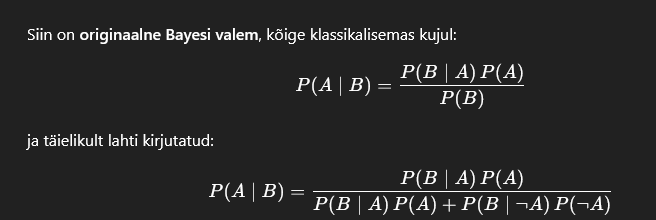


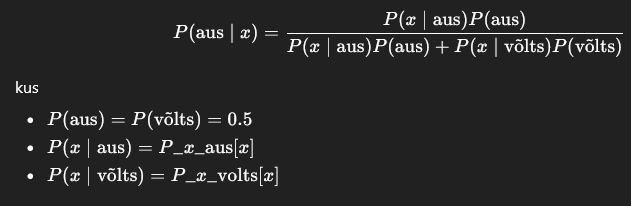


In [148]:

# P( Täring on aus | Viske tulemus ) = P(Täring on aus, Viske tulemus) / P(Viske tulemus)

# P(aus)
P_aus = 0.5

# P(võlts)
P_võlts = 0.5

# P(x | aus)
P_x_ting_aus = np.array([1/6]*6)

# P(x | võlts)
P_x_ting_võlts = np.array([0.02, 0.12, 0.12, 0.12, 0.12, 0.50])

# Ma ei tea P(aus | x) ja  P(Täring on aus, Viske tulemus)


for silmade_arv in range(6):
	P_aus_ting_x = \
	(
		P_x_ting_aus[silmade_arv] * P_aus
	) / (
		P_x_ting_aus[silmade_arv] * P_aus + P_x_ting_võlts[silmade_arv] * P_võlts
	)

	print(
		f"\n"
		f"Silmade arv {silmade_arv}:\n"
		f"\tP(Täring on aus | Viske tulemus) = {P_aus_ting_x:.4f}, { 'aus' if P_aus_ting_x >= 0.5 else 'võlts' }"
	)

	# HMM ennustus
	logprob, kõige_tn_tulemus = hmm.decode(np.array([[silmade_arv]]), algorithm="viterbi")
	print(
		f"\tHMM ennustus: {'aus' if kõige_tn_tulemus[0] == 0 else 'võlts'}"
	)



Silmade arv 0:
	P(Täring on aus | Viske tulemus) = 0.8929, aus
	HMM ennustus: aus

Silmade arv 1:
	P(Täring on aus | Viske tulemus) = 0.5814, aus
	HMM ennustus: aus

Silmade arv 2:
	P(Täring on aus | Viske tulemus) = 0.5814, aus
	HMM ennustus: aus

Silmade arv 3:
	P(Täring on aus | Viske tulemus) = 0.5814, aus
	HMM ennustus: aus

Silmade arv 4:
	P(Täring on aus | Viske tulemus) = 0.5814, aus
	HMM ennustus: aus

Silmade arv 5:
	P(Täring on aus | Viske tulemus) = 0.2500, võlts
	HMM ennustus: võlts


<font color='red'>Vastus:</font> ...


<font color='purple'>**(1c) Vaatleme mudelit, mis ennustab, et täring on võlts kui viske tulemus oli 5 ning vastasel juhul ennustab, et täring on aus. Arvutage ja raporteerige sellise mudeli täpsus andmetel `visete_tulemused` kus õiged vastused on massiivis `aus_või_võlts`.**</font>

<font color='purple'>**OODATUD VASTUS: Mudeli täpsus (näiteks protsentides).**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [149]:
#ennustus
_5_on_alati_võlts = (visete_tulemused.flatten() == 5).astype(int) # 1 kui 5, 0 muidu

täpsus = np.mean(_5_on_alati_võlts == aus_või_võlts)

print("Täpsus:", täpsus)

Täpsus: 0.59


<font color='red'>Vastus:</font> ...


<font color='purple'>**(1d) Rakendage Viterbi algoritmi, et leida andmete `visete_tulemused` alusel kõige tõenäolisem kahe täringu kasutamise järjend (ehk millisel viskel kasutati millist täringut). Uurige välja ja selgitage, mida tähendab `logprob` Viterbi algoritmi väljundis (logaritm mis tõenäosusest?).**</font>

<font color='purple'>**OODATUD VASTUS: Kõige tõenäolisem täringute kasutamise järjend; selgitus, mida tähendab `logprob` (1-3 lauset).**</font>

VIHJE:

-   Kasutage käsku: `logprob, tõenäolisim_järjend = hmm.decode(visete_tulemused, algorithm="viterbi")`

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [150]:
# Lahendus

logprob, toenaolisim_jarjend = hmm.decode(visete_tulemused, algorithm="viterbi")

print("Kõige tõenäolisem täringute kasutamise järjend:")
print(toenaolisim_jarjend)

print("\nlogprob =", logprob)

Kõige tõenäolisem täringute kasutamise järjend:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]

logprob = -529.6194906731442


<font color='red'>Vastus:</font> ...


In [151]:
# "viterbi": finds the most likely sequence of states, given all emissions.

# Viterbi algoritm otsib kõige tõenäolisemat peidetud olekute järjestust (hidden state sequence) HMM-is,

#Logprob Viterbi väljundis = logaritm tõenäosusest, et vaadeldud andmete järjestus tekkis just selle kõige tõenäolisema peidetud olekute jadast.

# mida suurem logprob, seda tõenäolisem on see ahel... hetkel -500 teheselt on väga väike tõenäosus


# Probabilities get very small when multiplying many of them (as in HMMs with long sequences).
# Using logarithms prevents underflow and converts products into sums

<font color='purple'>**(1e) Arvutage Viterbi algoritmi abil leitud ennustuste täpsus võrreldes tegelikult kasutatud täringute järjendiga `aus_või_võlts`. Milline punktides (1c) ja (1d) kasutatud meetoditest oli täpsem? Miks?**</font>

<font color='purple'>**OODATUD VASTUS: Viterbi täpsus, selgitus milline meetod oli täpsem ja miks (2-5 lauset).**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [152]:
import numpy as np

viterbi = toenaolisim_jarjend

accuracy = np.mean(viterbi == aus_või_võlts)
print(f"Viterbi täpsus: {accuracy:.2f}")

Viterbi täpsus: 0.65


<font color='red'>Vastus:</font> ...


In [153]:
# Viterbil oli täpsus parem kui eelneval mudelil, mis ennustas võltstäringut ainult siis kui tuli 5.


# Viterbi meetod on punktides 1c ja 1d kasutatud meetoditest täpsem, sest ta arvestab järjestuse kogu struktuuri ja üleminekute tõenäosusi, mitte ainult iga viset eraldi. See võimaldab paremini ära arvata, millist täringut iga viske ajal tegelikult kasutati, eriti kui täringute vahetus ei ole täiesti juhuslik.

<font color='purple'>**(1f) Arvutage tõenäosus, et kõikidel visetel kasutati ausat täringut (ja seega võltsi täringut ei kasutatud üldse) ja et seejuures oli kõigi visete tulemus just selline nagu massiivis `visete_tulemused`.**</font>

<font color='purple'>**OODATUD VASTUS: Tõenäosus.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [154]:
visete_tulemused.flatten()

array([5, 5, 5, 5, 4, 5, 5, 0, 4, 5, 5, 5, 5, 5, 4, 5, 5, 3, 3, 5, 4, 1,
       5, 1, 3, 4, 1, 2, 2, 2, 1, 1, 3, 1, 1, 4, 5, 1, 1, 1, 4, 4, 1, 0,
       5, 4, 4, 1, 0, 0, 1, 5, 3, 3, 5, 5, 1, 2, 3, 4, 3, 5, 5, 1, 1, 2,
       1, 3, 3, 2, 2, 5, 4, 5, 5, 5, 3, 5, 3, 0, 2, 5, 5, 2, 1, 0, 0, 1,
       5, 0, 3, 1, 5, 5, 3, 2, 5, 4, 2, 2, 4, 1, 0, 2, 5, 2, 3, 4, 2, 4,
       5, 4, 5, 1, 5, 2, 1, 4, 4, 5, 1, 1, 4, 2, 4, 5, 5, 1, 5, 3, 1, 5,
       4, 3, 2, 5, 5, 5, 5, 5, 5, 0, 2, 4, 5, 1, 2, 2, 5, 5, 5, 1, 2, 1,
       0, 2, 0, 1, 3, 4, 0, 1, 2, 4, 2, 4, 4, 4, 2, 1, 1, 0, 0, 1, 5, 0,
       3, 4, 0, 5, 5, 2, 2, 2, 5, 3, 5, 2, 5, 5, 4, 5, 5, 2, 4, 2, 5, 5,
       2, 1, 5, 5, 2, 1, 0, 2, 1, 1, 0, 3, 5, 2, 4, 1, 3, 5, 5, 4, 3, 4,
       5, 1, 3, 5, 5, 5, 1, 2, 1, 5, 3, 5, 2, 3, 2, 5, 5, 5, 5, 4, 1, 2,
       3, 5, 5, 5, 4, 3, 4, 5, 3, 5, 5, 1, 4, 3, 5, 5, 3, 5, 3, 4, 2, 5,
       2, 2, 1, 0, 4, 5, 3, 3, 0, 5, 3, 1, 5, 1, 4, 5, 1, 5, 5, 5, 5, 1,
       4, 3, 5, 5, 5, 1, 2, 0, 5, 5, 3, 5, 2, 5])

In [155]:
aste = len(visete_tulemused.flatten())
p_aus = 1/6

tn = p_aus**aste


print(f"Tõenäosus protsentides: {tn:.2e}")

log_tns_kokku = np.log(tn)
print(f"logprob {log_tns_kokku:.2f}")


Tõenäosus protsentides: 3.59e-234
logprob -537.53


<font color='red'>Vastus:</font> ...


<font color='purple'>**(1g) Arvutage tõenäosus, et kõikidel visetel kasutati võltsi täringut (ja seega ausat täringut ei kasutatud üldse) ja et seejuures oli kõigi visete tulemus just selline nagu massiivis `visete_tulemused`.**</font>

<font color='purple'>**OODATUD VASTUS: Tõenäosus.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [156]:
p_võlts = np.array([0.02, 0.12, 0.12, 0.12, 0.12, 0.50])

ühe_silma_tn = p_võlts[visete_tulemused.flatten()]

tn_kokku = np.prod(ühe_silma_tn)
log_tns_kokku = np.sum(np.log(ühe_silma_tn))

print(f"Tõenäosus protsentides: {tn_kokku:.2e}")
print(f"logprob {log_tns_kokku:.2f}")

Tõenäosus protsentides: 2.97e-230
logprob -528.50


<font color='red'>Vastus:</font> ...


<font color='purple'>**(1h) Viimaks arvutage tõenäosus, et ausat ja võltsi täringut kasutati just sellises järjekorras nagu ütleb `tõenäolisim_järjend` ning et seejuures visete tulemused on täpselt samad nagu massiivis `visete_tulemused`.**</font>

<font color='purple'>**OODATUD VASTUS: Tõenäosus.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [157]:
p_aus = 1/6
p_võlts = np.array([0.02, 0.12, 0.12, 0.12, 0.12, 0.50])
tõenäolisim_järjend = toenaolisim_jarjend

tns = np.zeros(len(visete_tulemused.flatten()))

for i, (vise, täring) in enumerate(zip(visete_tulemused.flatten(), tõenäolisim_järjend)):
    if täring == 0:
        tns[i] = p_aus
    else:
        tns[i] = p_võlts[vise]

tns_kokku = np.prod(tns)
log_tns_kokku = np.sum(np.log(tns))


print(f"ausat ja võltsi täringut kasutati samas järjekorras: {tns_kokku:.2e}")
print(f"logprob {log_tns_kokku:.2f}")

ausat ja võltsi täringut kasutati samas järjekorras: 3.27e-207
logprob -475.45


<font color='red'>Vastus:</font> ...


<font color='purple'>**(1i) Võrdle leitud tõenäosusi punktides (1f), (1g) ja (1h). Milline neist tõenäosustest on suurim ning kuidas seondub logaritm sellest tõenäosusest tulemustega punktis (1d)?**</font>

<font color='purple'>**OODATUD VASTUS: Selgitus, et milline tõenäosustest on suurim ning kuidas see seondub (1d) tulemustega.**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


<font color='red'>Vastus:</font> ...

Kõige tõenäolisem järjestus on Viterbi segu? mudel (1h), mille logprob on kõige väiksem.

| Punkt | Logprob | Kirjledus                      |
| ----- | ------- | ------------------------------ |
| 1d    | -529.62 | Viterbi                        |
| 1f    | -537.53 | kõik ausad täringud            |
| 1g    | -528.50 | kõik võltsid täringud          |
| 1h    | -475.45 | Viterbi kõige tõenäolisem segu |


# 2. ülesanne. Pildi puhastamine mürast: peidetud Markovi mudelid (3 punkti)


Selles ja järgmises ülesandes uurime kuidas saab tõenäosuslike graafiliste mudelite abil puhastada pilti mürast. Seejuures vaatleme müra, mis on tekitatud juhuslikult valitud pikslite värvi muutmisega juhuslikult valitud värviks. Põhimõtteliselt toimivad vaadeldavad meetodid mistahes värvide puhul, aga programmeerimistöö lihtsustamiseks teostame mürast puhastamist vaid halltoonides pildi puhul. Loeme kõigepealt sisse värvilise pildi:


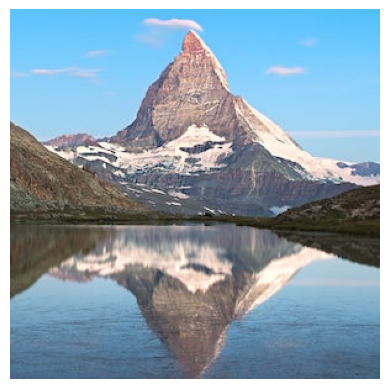

In [158]:
pilt_rgb = img.imread("pilt_300x300.jpg")
plt.imshow(pilt_rgb)
plt.axis('off')
plt.show()

In [159]:
type(pilt_rgb)

numpy.ndarray

In [160]:
pilt_rgb.shape

(300, 300, 3)

Näeme, et `pilt_rgb` pole midagi muud kui 3-mõõtmeline `numpy` massiiv, kus mõõtmeteks on kõrgus (300 pikslit), laius (300 pikslit) ning värvikanal, kus kolmeks kanaliks on punane (Red), roheline (Green) ja sinine (Blue) ehk kokku RGB. Massiivis sisalduvad täisarvud vahemikus 0,1,...,255, kus kohal `pilt_rgb[i,j,k]` asuv väärtus tähistab seda, kui suur on i-ndal real ja j-ndas veerus asuva piksli intensiivsus k-ndal värvikanalil. Seejuures arv 255 tähendab maksimaalset intensiivsust ning arv 0 minimaalset. Näiteks üleval vasakul nurgas on piksel, mille RGB värvikood on 94, 194, 254:


In [161]:
pilt_rgb[0,0,:]

array([ 94, 194, 254], dtype=uint8)

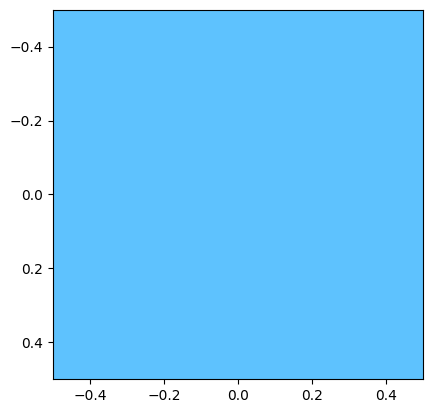

In [162]:
plt.imshow(pilt_rgb[0:1,0:1,:])

See tähendab, et sellel pikslil on punase intensiivsus 94/255, rohelise intensiivsus 194/255 ning sinise intensiivsus peaaegu maksimaalne 254/255.


Esimese sammuna teisendame pildi halltoonidesse. Halltoonid on värvid, kus on nii punast, rohelist kui sinist sama palju ehk kõigil kolmel kanalil on sama väärtus. RGB piksli halltooni teisendamiseks leiame kõigepealt tema kolme värvikomponendi intensiivsuste keskmise. Seejärel määrame kõigi värvikanalite intensiivsused võrdseks selle keskmisega:


In [163]:
keskmine = np.mean(pilt_rgb[0,0,:])
halltoon = np.round(np.array([keskmine,keskmine,keskmine])).astype(int)
halltoon

array([181, 181, 181])

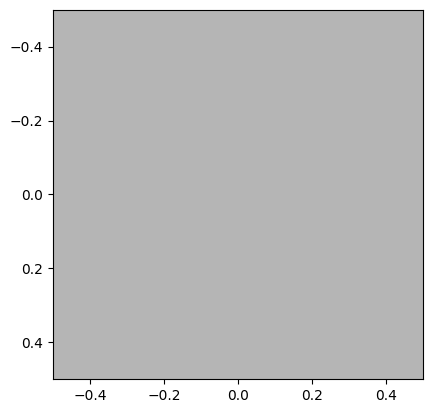

In [164]:
plt.imshow(np.array([[halltoon]]))

Selle metoodikaga asendame kõigi pikslite kõikide värvikanalite väärtused vastavalt selle piksli RGB värvikanalite keskmisega:


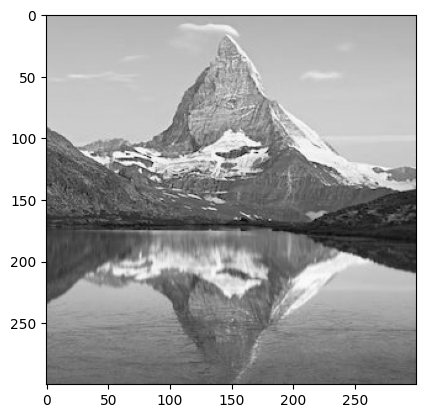

In [165]:
pilt_hall = pilt_rgb.copy()
pilt_hall[:,:,0] = np.round(pilt_rgb.mean(axis=2)).astype(int)
pilt_hall[:,:,1] = pilt_hall[:,:,0]
pilt_hall[:,:,2] = pilt_hall[:,:,0]
plt.imshow(pilt_hall)

Kuna nüüd sisaldavad kõik värvikanalid täpselt samu väärtusi, siis ei ole enam mitut värvikanalit vaja, piisab ühest. Nõnda saame kolmemõõtmelise massiivi asemel hakata töötama kahemõõtmelise massiiviga. Ka `plt.imshow` oskab selliseid kahemõõtmelisi massiive pildina näidata:


In [166]:
pilt = pilt_hall[:,:,0].copy()
pilt.shape

(300, 300)

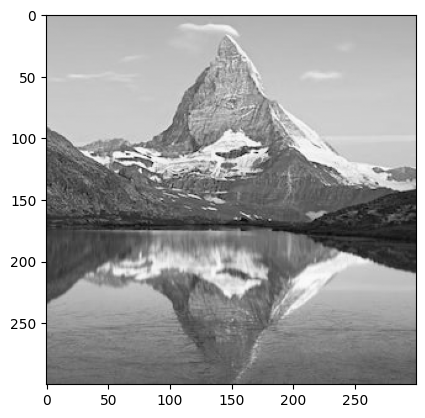

In [167]:
plt.imshow(pilt, cmap='gray')

Järgmisena tekitame pildile müra. Kuigi põhimõtteliselt on võimalik üpris edukalt müra eemaldada ka juhul kui müra katab terve pildi, siis teeme oma elu pisut lihtsamaks (ja hilisemad arvutused kiiremaks) ning lisame müra vaid ühte ristkülikukujulisse piirkonda, ridadele 20-280 ja veergudele 220-280. Selles piirkonnas otsustame iga piksli kohta sõltumatult, kas see saab müraks (tõenäosusega 0.1) või jääb piksli värv samaks (tõenäosusega 0.9). Mürase piksli puhul valime uue värvi ühtlaselt juhuslikult väärtuste 0,1,...,255 seast.


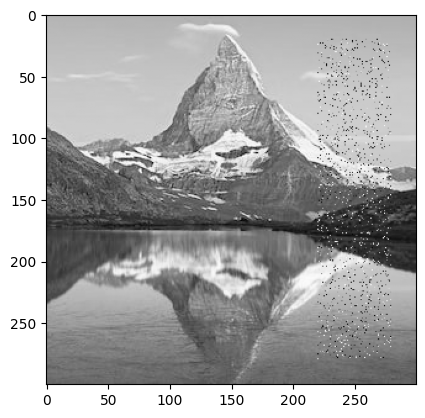

In [168]:
r1 = 20 # rida kust müra algab
r2 = 280 # ja lõpeb
v1 = 220 # veerg kust müra algab
v2 = 280 # ja lõpeb
rng = np.random.default_rng(0)
müra_tõenäosus = 0.1
kas_müra = rng.choice([0,1],size=pilt.shape,p=[1-müra_tõenäosus,müra_tõenäosus])
kas_müra[:r1,:] = 0 # see ja järgnevad alad jääb ristkülikust välja ning siia müra ei pane
kas_müra[r2:,:] = 0
kas_müra[:,:v1] = 0
kas_müra[:,v2:] = 0
müra = rng.integers(0,256,size=pilt.shape)
mürane_pilt = kas_müra*müra + (1-kas_müra)*pilt
plt.imshow(mürane_pilt, cmap='gray')

Vaatame lähemalt ala, mis jääb ridadele 120-130 ning mürastele veergudele 220-280:


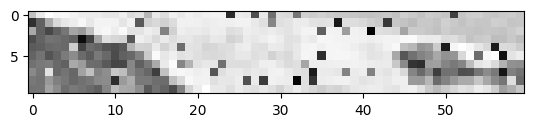

In [169]:
plt.imshow(mürane_pilt[120:130,220:280], cmap='gray')

Nüüd asume selliseid ridu ükshaaval peidetud Markovi mudeliga (HMM-iga) puhastama. Kõigepealt alustame reast numbriga 125, mis näeb mürasena välja nii:


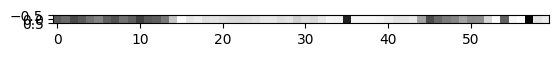

In [170]:
plt.imshow(mürane_pilt[125:126,220:280], cmap='gray')

Kuna nii on piksleid pisut ebamugav vaadata, siis venitame seda riba 3x laiemaks:


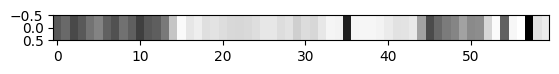

In [171]:
plt.imshow(mürane_pilt[125:126,220:280], cmap='gray', aspect=3)

Võrdluseks näeb ilma mürata algsel pildil sama riba välja nii:


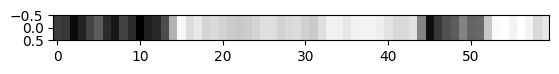

In [172]:
plt.imshow(pilt[125:126,220:280], cmap='gray', aspect=3)

Erinevusi on vähe ja neid on pisut raske märgata, aga kokku on siin müraseid piksleid:


In [173]:
np.sum(mürane_pilt[125:126,220:280] != pilt[125:126,220:280])

np.int64(5)

HMM-i defineerimise jaoks on meil vaja fikseerida kõikvõimalikud olekud - need saavad olema värvid 0,1,...,255. Peidetud olekuteks, mida ära arvata soovime, saavad olema algsed värvid rea 125 veergudes 220-280 ning vaatlusteks saavad olema mürase pildi pikslid samades kohtades ehk samuti rea 125 veergudes 220-280.

Seejärel on vaja defineerida tõenäosusjaotus üle kõikvõimalike algolekute ning ka üleminekutõenäosuste maatriks. Ja muidugi ka iga algse piksli värvi puhul tõenäosusjaotus üle vastava piksli värvi mürasel pildil. Seejärel on võimalik rakendada Viterbi algoritmi ning leida kõige tõenäolisemad väärtused algsetele pikslitele.


<font color='red'>**NB! Ükski arvutus ei tohi kasutada algset pilti `pilt` vaid tohib kasutada ainult mürast pilti `mürane_pilt`, välja arvatud siis kui ülesandeks on otseselt mõõta kui hästi on taastamine õnnestunud.</font>**


<font color='purple'>**(2a) Leidke mürase pildi vasaku poole (kõik read ja veerud 0-150) järgi värvide sagedused ning visualiseerige see jaotus. Salvestage tulemus 256-elemendilisse massiivi `värvide_sagedused`, kus kohal i on värvi i esinemissagedus täisarvuna.**</font>

<font color='purple'>**OODATUD VASTUS: Joonis.**</font>

VIHJE:

-   Visualiseerimiseks võib näiteks kasutada järgmisi käske (kus y-telje skaala on suhteliselt suvaline - väärtus 10 tähendab sagedaseima värvi sagedust - aga siiski on näha suhtelisi sagedusi ning all värviskaalat):
    `plt.imshow([np.arange(256)],cmap='gray',aspect=10,origin='lower')`
    `plt.plot(range(256),10*värvide_sagedused/max(värvide_sagedused),linewidth=3)`

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


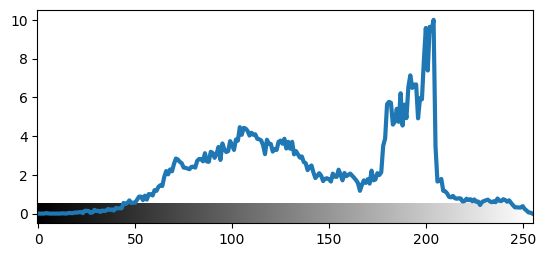

In [174]:
vasak_pool = mürane_pilt[:, 0:150]

värvide_sagedused = np.zeros(256, dtype=int)

for värv in range(256):
	värvide_sagedused[värv] = np.sum(vasak_pool == värv)

plt.imshow([np.arange(256)], cmap='gray', aspect=10, origin='lower')
plt.plot(range(256), 10 * värvide_sagedused / max(värvide_sagedused), linewidth=3)

<font color='purple'>**(2b) Leidke mürase pildi vasaku poole (kõik read ja veerud 0-150) järgi kõigi värvipaaride (kaasa arvatud iga värv iseendaga paaris) kõrvuti esinemise sagedused. Kõrvuti tähendab kas üksteise järel mingil real või üksteise all mingis veerus, ükskõik mis järjekorras. Salvestada tulemus `numpy` maatriksina ehk 2-mõõtmelise massiivina `värvipaaride_sagedused`, kus real i ja veerus j on värvide i ja j kõrvuti esinemise sagedus, mis loeb kokku mitu korda esineb värv i värvist j vasakul või paremal või üleval või all (kui i=j, siis tuleks iga kõrvuti esinemist lugeda kahekordselt).**</font>

<font color='purple'>**Lugege kokku, kas selles maatriksis on rohkem nulle või rohkem nullist erinevaid sagedusi. Joonistage selle maatriksi diagonaal üles sarnase joonisena nagu punktis (2a).**</font>

<font color='purple'>**OODATUD VASTUS: Maatriksi diagonaalil olevate sageduste joonis; vastus, et kas on rohkem nulle või mitte-nulle (1 lause).**</font>

VIHJE:

-   Kui peaksite siin eksima väikeste detailidega (näiteks i=j pole kahekordselt loetud), siis selle mõju ei ole eriti suur edasisele analüüsile, nii et sel juhul saate ikka täispunktid.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


Nulle: 46070, Mitte-nulle: 19466


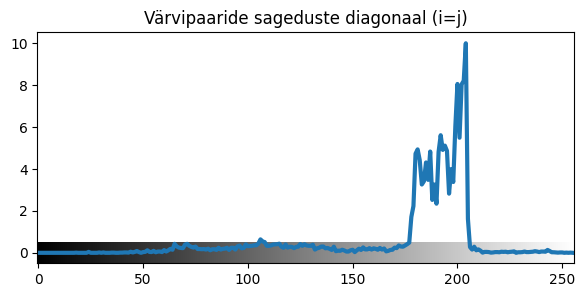

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 0]]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    2    0    0    0    0    0   10    0    0    0
    0    4    0    4    0    0    0    2    2    0    0    2    2    4
    4    2   12    4   10   20    8    0    8   10   28   10    8   22
    6   14   14    8   30   14   28   44   34  100   72   58   54   52
   92  100   78   66   58   70   42   42   40   42   36   46   28   40
   40   32   56   36   44   46   56   32   56   56   36   72   80   50
   54   94   74   76   78   84   84  104  150  126  120   78   78   82
   92   94   96  102   68   56   94   58   68   66   52   66   68   98
   78   96   82   78   78   90   36   50   56   70   70   50   54   44
   32   68   18   24   22   34   26   14   14   28   34    8   28   46
   32   60   38   38   52   36   50   44   34   54   36   48   16   22
   32   34   58   52   82   

In [175]:
värvipaaride_sagedused = np.zeros((256, 256), dtype=int)

ridu, veerge = vasak_pool.shape


# Kõrvuti horisontaalselt (vasak-parem)
for i in range(ridu):
    for j in range(veerge-1):
        v1 = vasak_pool[i,j]
        v2 = vasak_pool[i,j+1]
        värvipaaride_sagedused[v1, v2] += 1
        värvipaaride_sagedused[v2, v1] += 1 # sümmeetriline

# Kõrvuti vertikaalselt (ülemine-all)
for i in range(ridu-1):
    for j in range(veerge):
        v1 = vasak_pool[i,j]
        v2 = vasak_pool[i+1,j]
        värvipaaride_sagedused[v1, v2] += 1
        värvipaaride_sagedused[v2, v1] += 1  # sümmeetriline

n_nulle = np.sum(värvipaaride_sagedused == 0)
n_mitte_nulle = np.sum(värvipaaride_sagedused != 0)

print(f"Nulle: {n_nulle}, Mitte-nulle: {n_mitte_nulle}")

diagonaal = np.diag(värvipaaride_sagedused)

plt.figure(figsize=(12,3))
plt.imshow([np.arange(256)], cmap='gray', aspect=10, origin='lower')
plt.plot(range(256), 10 * diagonaal / max(diagonaal), linewidth=3)
plt.title("Värvipaaride sageduste diagonaal (i=j)")
plt.show()

print(värvipaaride_sagedused)

print(diagonaal)

<font color='red'>Vastus:</font> ...


<font color='purple'>**(2c) Kasutades eelmistes alapunktides saadud tulemusi, defineerime peidetud Markovi mudeli (HMM), kasutame seda pildi puhastamiseks ning uurime kui hästi see õnnestus.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Algolekute jaotuse määrab massiiv `värvide_sagedused`. Peate massiivi summaga läbi jagama, et saaks tõenäosusjaotuse.**</font>

2. <font color='purple'>**Üleminekutõenäosuste saamiseks tehke koopia maatriksist `värvipaaride_sagedused` ning jagage iga rea liikmed läbi rea summaga, et moodustuks tõenäosusjaotus. Kui mõne rea summa on 0, siis üleminekutõenäosuste maatriksis asendage see nullide rida ühtlasele jaotusele vastava `1/256` reaga.**</font>

3. <font color='purple'>**Sümbolite (antud juhul on sümboliteks värvid) väljastamise tõenäosusjaotused on sellised, et tõenäosusega `1-müra_tõenäosus` väljastatakse sama värv ning tõenäosusega `müra_tõenäosus` väljastatakse värv ühtlaselt juhuslikult väärtuste 0,1,...,255 seast.**</font>
4. <font color='purple'>**Võttes vaatlustena ette 60 pikslit mürase pildi real numbriga 125 ja veergudes 220-280 (280 välja arvatud), leidke Viterbi algoritmi abil nende pikslite kõige tõenäolisemad algsed värvid enne müra lisamist.**</font>

5. <font color='purple'>**Tehke 3 joonist kus on need 60 pikslit enne müra lisamist, koos müraga ning peale müra eemaldamist.**</font>

6. <font color='purple'>**Mõõtke mõõduga RMSE (_root mean squared error_ ehk ruutjuur keskmisest ruuterinevusest), kui suur on erinevus müraga pikslite ja õigete ilma mürata pikslite vahel; ning kui suur on erinevus Viterbi algoritmiga puhastatud pikslite ning õigete ilma mürata pikslite vahel. Kas puhastamisest oli kasu (mürane piksel parandatud ligikaudu õigeks) või kahju (ilma mürata piksel ära muudetud valeks)?**</font>

<font color='purple'>**NB! Ärge massiivis `mürane_pilt` muutusi tehke. Parem tehke sellest koopia ning siis võite puhastamist nii siin kui järgmises alamülesandes teha selle koopia peal.**</font>

<font color='purple'>**OODATUD VASTUS: 3 joonist; RMSE enne ja pärast puhastamist; kas RMSE kahanes ja kas puhastamisest oli kasu või kahju (2-3 lauset).**</font>

VIHJE:

-   HMM-i ja Viterbi algoritmi kasutamiseks vaadake koodi 1. ülesandest.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [176]:
from hmmlearn.hmm import CategoricalHMM

In [177]:
# 1
# 	Algolekute jaotuse määrab massiiv värvide_sagedused. Peate massiivi summaga läbi jagama, et saaks tõenäosusjaotuse.

algolekud = värvide_sagedused / np.sum(värvide_sagedused)

In [244]:
# 2
# 	Üleminekutõenäosuste saamiseks tehke koopia maatriksist värvipaaride_sagedused ning jagage iga rea liikmed läbi rea summaga, et moodustuks tõenäosusjaotus. Kui mõne rea summa on 0, siis üleminekutõenäosuste maatriksis asendage see nullide rida ühtlasele jaotusele vastava 1/256 reaga.

värvipaaride_sagedused_koopia = värvipaaride_sagedused.copy().astype(float)

üleminekutõenäosuste = np.zeros((256,256))

for i, rida in enumerate(värvipaaride_sagedused_koopia):
    rea_summa = np.sum(rida)

    if rea_summa == 0:
        üleminekutõenäosuste[i] = 1/256
    else:
        üleminekutõenäosuste[i] = rida / rea_summa
        #üleminekutõenäosuste = üleminekutõenäosuste / üleminekutõenäosuste.sum(axis=1, keepdims=True)

    #print(np.sum(üleminekud[i,:]))      # Kontroll, et rida summa on 1

	#print(f"Rida {i} summa: {rea_summa}")
	#print(f"Üleminekud rida {i}: {üleminekud[i,:]}")

#üleminekutõenäosuste.sum(axis=-1)

In [239]:
# 3
# 	Sümbolite (antud juhul on sümboliteks värvid) väljastamise tõenäosusjaotused on sellised, et tõenäosusega 1-müra_tõenäosus väljastatakse sama värv ning tõenäosusega müra_tõenäosus väljastatakse värv ühtlaselt juhuslikult väärtuste 0,1,...,255 seast.

müra_tõenäosus = 0.1

väljastamis_tõenäosused = np.zeros((256,256))

for värv in range(256):
	väljastamis_tõenäosused[värv, värv] = 1 - müra_tõenäosus
	väljastamis_tõenäosused[värv, :] += müra_tõenäosus / 256

In [243]:
#väljastamis_tõenäosused.sum(axis=-1)

In [241]:
hmm = CategoricalHMM(n_components = len(algolekud), init_params="", random_state=0)

hmm.startprob_ = algolekud
hmm.transmat_ = üleminekutõenäosuste
hmm.emissionprob_ = väljastamis_tõenäosused

In [247]:
# 4
# 	Võttes vaatlustena ette 60 pikslit mürase pildi real numbriga 125 ja veergudes 220-280 (280 välja arvatud), leidke Viterbi algoritmi abil nende pikslite kõige tõenäolisemad algsed värvid enne müra lisamist.

vaatlused = mürane_pilt[125, 220:280].reshape(-1,1)
logprob, müra_eemaldatud_pilt = hmm.decode(vaatlused, algorithm="viterbi")

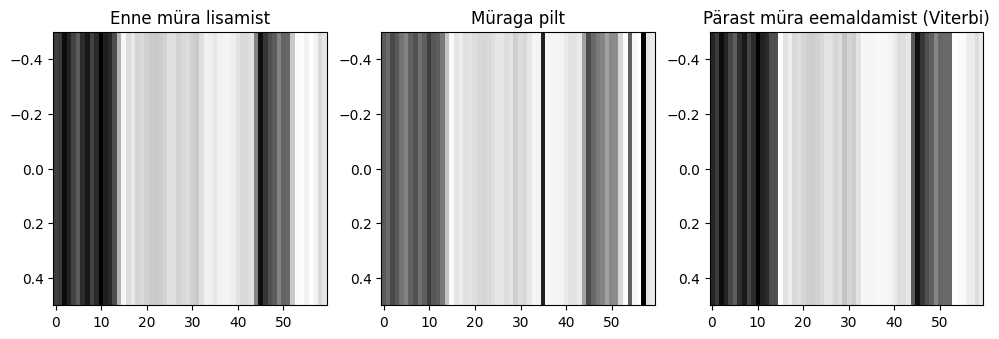

In [248]:
# 5
# 	Tehke 3 joonist kus on need 60 pikslit enne müra lisamist, koos müraga ning peale müra eemaldamist.

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Enne müra lisamist")
plt.imshow(pilt[125,220:280].reshape(1,-1), cmap='gray', aspect=60)
plt.subplot(1,3,2)
plt.title("Müraga pilt")
plt.imshow(mürane_pilt[125,220:280].reshape(1,-1), cmap='gray', aspect=60)
plt.subplot(1,3,3)
plt.title("Pärast müra eemaldamist (Viterbi)")
plt.imshow(müra_eemaldatud_pilt.reshape(1,-1), cmap='gray', aspect=60)
plt.show()


In [250]:
# 6
# 	Mõõtke mõõduga RMSE (root mean squared error ehk ruutjuur keskmisest ruuterinevusest), kui suur on erinevus müraga pikslite ja õigete ilma mürata pikslite vahel; ning kui suur on erinevus Viterbi algoritmiga puhastatud pikslite ning õigete ilma mürata pikslite vahel. Kas puhastamisest oli kasu (mürane piksel parandatud ligikaudu õigeks) või kahju (ilma mürata piksel ära muudetud valeks)?

from sklearn.metrics import mean_squared_error
from math import sqrt

vaadeldud_indeksid = (125, slice(220,280))

rmse_mürane = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], mürane_pilt[vaadeldud_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], müra_eemaldatud_pilt))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")


RMSE mürane pilt vs originaal: 42.96
RMSE puhastatud pilt vs originaal: 13.99


In [258]:
np.sum(pilt[vaadeldud_indeksid] != mürane_pilt[vaadeldud_indeksid])

np.int64(5)

In [259]:
np.sum(pilt[vaadeldud_indeksid] != müra_eemaldatud_pilt)

np.int64(9)

<font color='red'>Vastus:</font> ...


In [ ]:
# Pigem oli kasu, sest RMSE väärtus pärast puhastamist on väiksem kui mürase pildi puhul.

<font color='purple'>**(2d) Kasutame punktis (2c) defineeritud HMM mudelit selleks, et puhastada mürast kogu pilt.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Punktis (2c) puhastasite rea numbriga 125, nüüd rakendage sama mudelit kogu mürase ristküliku (read 20-280 ja veerud 220-280) puhastamiseks.**</font>

2. <font color='purple'>**Joonistage välja puhastatud pilt.**</font>

3. <font color='purple'>**Arvutage RMSE üle kõigi pikslite mürases ristkülikus enne ja pärast müra eemaldamist. Kas RMSE paranes ning kas puhastamisest oli kasu või kahju?**</font>

<font color='purple'>**OODATUD VASTUS: 1 joonis; RMSE enne ja pärast puhastamist; kas RMSE kahanes ja kas puhastamisest oli kasu või kahju (2-3 lauset).**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


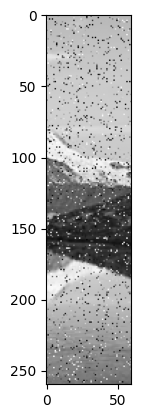

In [255]:
puhastatav_pilt = mürane_pilt.copy()[20:280, 220:280]
puhas_pilt = pilt.copy()[20:280, 220:280]

plt.imshow(puhastatav_pilt, cmap='gray')
plt.show()

#plt.imshow(puhas_pilt, cmap='gray')
#plt.show()

In [311]:
algolekud = värvide_sagedused / np.sum(värvide_sagedused)

###

värvipaaride_sagedused_koopia = värvipaaride_sagedused.copy().astype(float)

üleminekutõenäosuste = np.zeros((256,256))

for i, rida in enumerate(värvipaaride_sagedused_koopia):
    rea_summa = np.sum(rida)

    if rea_summa == 0:
        üleminekutõenäosuste[i] = 1/256
    else:
        üleminekutõenäosuste[i] = rida / rea_summa

###

müra_tõenäosus = 0.1

väljastamis_tõenäosused = np.zeros((256,256))

for värv in range(256):
    #väljastamis_tõenäosused[värv, :] = müra_tõenäosus / 256
    #väljastamis_tõenäosused[värv, värv] = 1 - müra_tõenäosus + (müra_tõenäosus / 256)
	väljastamis_tõenäosused[värv, värv] = 1 - müra_tõenäosus
	väljastamis_tõenäosused[värv, :] += müra_tõenäosus / 256

###


hmm = CategoricalHMM(n_components = len(algolekud), init_params="", random_state=0)

hmm.startprob_ = algolekud
hmm.transmat_ = üleminekutõenäosuste
hmm.emissionprob_ = väljastamis_tõenäosused

vaatlused = mürane_pilt[20:280, 220:280].reshape(-1,1)
logprob, müra_eemaldatud_pilt = hmm.decode(vaatlused, algorithm="viterbi")

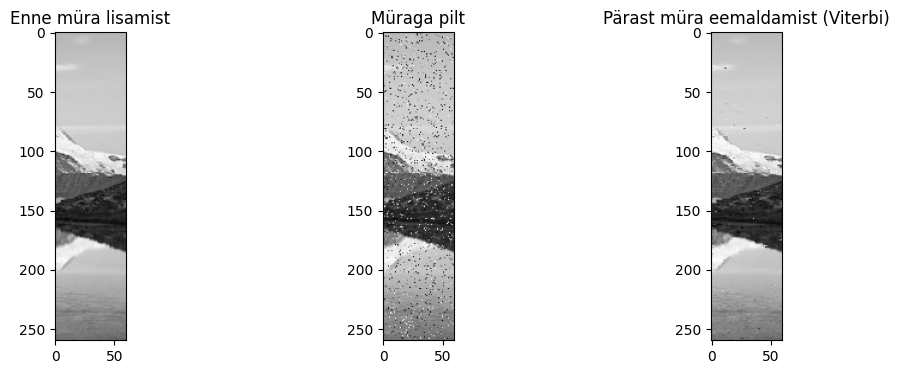

In [312]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Enne müra lisamist")
plt.imshow(pilt[20:280, 220:280], cmap='gray')
plt.subplot(1,3,2)
plt.title("Müraga pilt")
plt.imshow(mürane_pilt[20:280, 220:280], cmap='gray')
plt.subplot(1,3,3)
plt.title("Pärast müra eemaldamist (Viterbi)")
plt.imshow(müra_eemaldatud_pilt.reshape(280-20, 280-220), cmap='gray')
plt.show()

In [314]:
vaadeldud_indeksid = (slice(20,280), slice(220,280))

rmse_mürane = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], mürane_pilt[vaadeldud_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], müra_eemaldatud_pilt.reshape(280-20, 280-220)))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")


RMSE mürane pilt vs originaal: 31.51
RMSE puhastatud pilt vs originaal: 8.81


<font color='red'>Vastus:</font> ...


<font color='purple'>**(2e) Uurime, kui hästi töötab selline puhastamise meetod kõrgema müratasemega.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Looge rohkema müraga pildid `mürane_pilt_03` ja `mürane_pilt_05`, kus müra tase on vastavalt 0.3 ja 0.5.**</font>

2. <font color='purple'>**Korrake mürast puhastamise protseduuri, kusjuures iga mürataseme jaoks looge uus HMM (muutub sümbolite väljastamise tõenäosuse maatriks)**</font>

3. <font color='purple'>**Joonistage mõlemast müratasemest pilt enne ja pärast puhastamist ning arvutage ka RMSE mürases ristkülikus. Kas mõlemal müratasemel RMSE paranes ning kas puhastamisest oli kasu või kahju?**</font>

<font color='purple'>**OODATUD VASTUS: 4 pilti ja 4 RMSE väärtust (mõlemal müratasemel enne ja pärast müra eemaldamist); selgitus, kas mõlemal müratasemel RMSE kahanes ja kas puhastamisest oli kasu või kahju (2-3 lauset).**</font>

VIHJE:

-   Kasuta eelnevates alapunktides olevat koodi, soovitatav on see ümber kirjutada funktsioonidesse. Näiteks soovitud müratasemega mürase pildi loomiseks kirjuta funktsioon `def lisa_müra(pilt, müratase):`.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [302]:
def joonista(lisatud_müraga_pilt, müra_eemaldatud_pilt):
	plt.figure(figsize=(12,4))
	plt.subplot(1,3,1)
	plt.title("Enne müra lisamist")
	plt.imshow(pilt[20:280, 220:280], cmap='gray')
	plt.subplot(1,3,2)
	plt.title("Müraga pilt")
	plt.imshow(lisatud_müraga_pilt[20:280, 220:280], cmap='gray')
	plt.subplot(1,3,3)
	plt.title("Pärast müra eemaldamist (Viterbi)")
	plt.imshow(müra_eemaldatud_pilt.reshape(280-20, 280-220), cmap='gray')
	plt.show()

In [290]:
# Lahendus

def lisa_müra(pilt, müratase = 0.1):
	r1 = 20 # rida kust müra algab
	r2 = 280 # ja lõpeb
	v1 = 220 # veerg kust müra algab
	v2 = 280 # ja lõpeb

	pilt = pilt.copy()

	rng = np.random.default_rng(0)
	müra_tõenäosus = müratase

	kas_müra = rng.choice([0,1],size=pilt.shape,p=[1-müra_tõenäosus,müra_tõenäosus])
	kas_müra[:r1,:] = 0 # see ja järgnevad alad jääb ristkülikust välja ning siia müra ei pane
	kas_müra[r2:,:] = 0
	kas_müra[:,:v1] = 0
	kas_müra[:,v2:] = 0

	müra = rng.integers(0,256,size=pilt.shape)
	mürane_pilt = kas_müra*müra + (1-kas_müra)*pilt
	return mürane_pilt

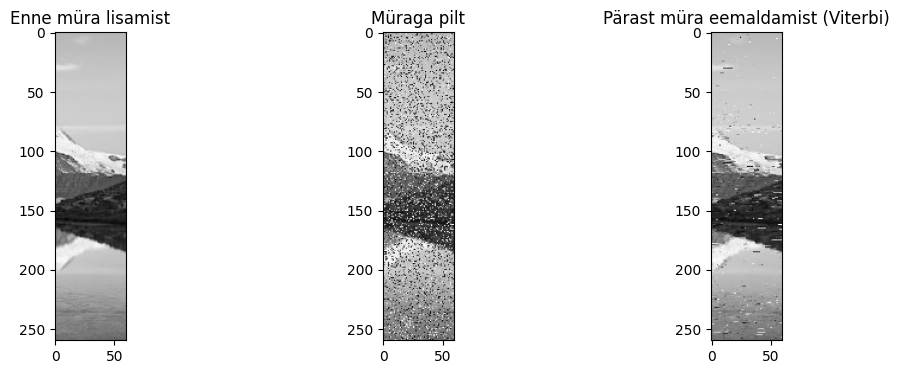

In [319]:
mürane_pilt_03 = lisa_müra(pilt, 0.3)
vaatlused = mürane_pilt_03[20:280, 220:280].reshape(-1,1)
logprob, müra_eemaldatud_pilt = hmm.decode(vaatlused, algorithm="viterbi")
joonista(mürane_pilt_03, müra_eemaldatud_pilt)

In [320]:
vaadeldud_indeksid = (slice(20,280), slice(220,280))

rmse_mürane = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], mürane_pilt_03[vaadeldud_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], müra_eemaldatud_pilt.reshape(280-20, 280-220)))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")


RMSE mürane pilt vs originaal: 54.97
RMSE puhastatud pilt vs originaal: 17.57


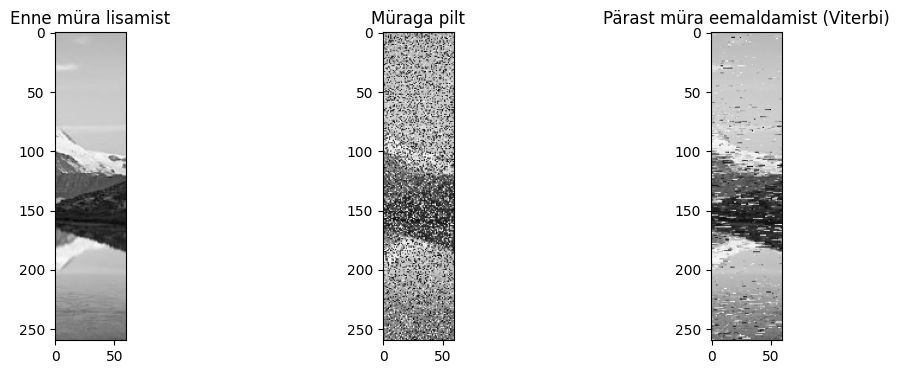

In [321]:
mürane_pilt_05 = lisa_müra(pilt, 0.5)
vaatlused = mürane_pilt_05[20:280, 220:280].reshape(-1,1)
logprob, müra_eemaldatud_pilt = hmm.decode(vaatlused, algorithm="viterbi")
joonista(mürane_pilt_05, müra_eemaldatud_pilt)

In [323]:
vaadeldud_indeksid = (slice(20,280), slice(220,280))

rmse_mürane = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], mürane_pilt_05[vaadeldud_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadeldud_indeksid], müra_eemaldatud_pilt.reshape(280-20, 280-220)))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")


RMSE mürane pilt vs originaal: 70.76
RMSE puhastatud pilt vs originaal: 30.10


<font color='red'>Vastus:</font> ...


# 3. ülesanne (Vabatahtlik boonusülesanne). Pildi puhastamine mürast: Markovi juhuslikud väljad (2 punkti)


HMM-i puhul kasutasime müra puhastamisel vaid üht rida korraga. Markovi juhuslikud väljad võimaldavad puhastamisel arvesse võtta iga punkti naaberpiksleid mitte ainult samal real vaid ka üleval ja all.

Meie kasutatava Markovi juhusliku välja struktuur on sarnane, mis on toodud 8. loengu (Tõenäosuslikud graafilised mudelid) slaidil 60 (Näide: pildilt müra eemaldamine). Põhimõtteliselt saaks arvestada ka näiteks diagonaalis asuvaid naaberpiksleid või ka veel kaugemaid piksleid, aga seda me antud ülesandes ei tee. Mürase pildi põhjal kõige tõenäolisema algse pildi leidmiseks on vaja leida pilt, mille puhul on faktorite korrutis maksimaalne. See on nii paljude tunnuste (ehk pikslite) korral üpris keeruline ülesanne, mille lahendamiseks on mitmeid keerulisi meetodeid. Meie vaatame aga väga lihtsat (ja pisut kehvemat) meetodit.

Meie meetod algab oletusest, et pilt on juba puhas ehk algväärtustame puhastatud pildi pikslid $x_{i,j}$ mürase pildi pikslitega $y_{i,j}$. Edasi hakkame käima järjest kõiki piksleid läbi ning iga piksli korral vaatame, kas pikslile $x_{i,j}$ saab leida parema väärtuse, mille korral on faktorite korrutis suurem (ja seega oleme leidnud tõenäolisema kandidaadi puhastatud pildile). Kui kõik pikslid on läbi käidud (vajadusel mitu korda), siis olemegi loodetavasti pikslitega $x_{i,j}$ jõudnud lähemale algsele puhtale pildile.


<font color='purple'>**(3a) Puhastame pildil `mürane_pilt` kõigepealt rea numbriga 125 veergudes 220-280.**</font>

<font color='purple'>**JUHISED:**</font>

1. <font color='purple'>**Joonistage mürasest pildist välja read 124, 125 ja 126 veergudes 220-280. Puhastamist alustage rea i=125 veeru j=220 pikslist $x_{i,j}$. See piksel $x_{i,j}$ sisaldub viies faktoris:**</font>

    - <font color='purple'>**$(x_{i,j},x_{i-1,j})$**</font>
    - <font color='purple'>**$(x_{i,j},x_{i+1,j})$**</font>
    - <font color='purple'>**$(x_{i,j},x_{i,j-1})$**</font>
    - <font color='purple'>**$(x_{i,j},x_{i,j+1})$**</font>
    - <font color='purple'>**$(x_{i,j},y_{i,j})$**</font>

2. <font color='purple'>**Nelja esimese faktorina kasutage sama maatriksit `värvipaaride_sagedused`, mille arvutasite välja ülesande 2 punktis (2b), kuid liitke sellele konstant `0.0001`, et mudel ühtki värvikombinatsiooni päris võimatuks ei peaks (ehk kasutage maatriksit `värvipaaride_sagedused+0.0001`).**</font>

3. <font color='purple'>**Viies faktor olgu muidu väärtusega `1`, välja arvatud juhul kui $x_{i,j}=y_{i,j}$, mis puhul olgu selle faktori väärtuseks `1/müra_tõenäosus`. Proovige läbi $x_{i,j}$ kõik võimalikud väärtused 0,1,...,255 ning valige $x_{i,j}$ väärtus selliselt, et viie faktori korrutis tuleks suurim võimalik.**</font>
4. <font color='purple'>**Selliselt toimige järjest kõigi rea 125 pikslitega veergudes 220-280 ning korrake sama protsessi teist korda veel. Seejärel joonistage välja puhastatud reaga pildi read 124, 125 ja 126 veergudes 220-280. Kas rida 125 läks puhtamaks? Arvutage RMSE sellel real. Kas puhastamine õnnestus paremini või halvemini kui HMM-iga puhastades?**</font>

<font color='red'>**NB! Puhastage mitte pilti `mürane_pilt` vaid selle koopiat.**</font>

<font color='purple'>**OODATUD VASTUS: Pildi 3 rida enne ja pärast puhastamist; rea 125 RMSE enne ja pärast puhastamist; selgitus kui hästi puhastamine õnnestus.**</font>

VIHJE:

-   Kui `värvipaaride_sagedused` maatriksi mõne elemendi väärtust muudeti eelmise ülesande koodis, siis arvutage see maatriks uuesti välja.

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [460]:
import numpy as np
import matplotlib.pyplot as plt


puhastatud_pilt = mürane_pilt.copy()

i_center = 125
rows = np.array([124, 125, 126])
cols = np.arange(220, 280)


vaadelavad_indeksid = (slice(124, 126), slice(220, 280))

In [461]:
freqs = värvipaaride_sagedused + 0.0001

def faktorite_korrutis(x_ij, i, j):
    y_ij = mürane_pilt[i, j]

    f1 = freqs[x_ij, puhastatud_pilt[i-1, j]]
    f2 = freqs[x_ij, puhastatud_pilt[i+1, j]]
    f3 = freqs[x_ij, puhastatud_pilt[i, j-1]]
    f4 = freqs[x_ij, puhastatud_pilt[i, j+1]]

    # Viies faktor
    if x_ij == y_ij:
        f5 = 1 / müra_tõenäosus
    else:
        f5 = 1

    return f1 * f2 * f3 * f4 * f5


In [462]:
for _ in range(2):
    for j in cols:
        i = i_center
        parim_x = None
        max_faktor = -np.inf

        for x_ij in range(256):
            faktor = faktorite_korrutis(x_ij, i, j)
            if faktor > max_faktor:
                max_faktor = faktor
                parim_x = x_ij
        puhastatud_pilt[i, j] = parim_x


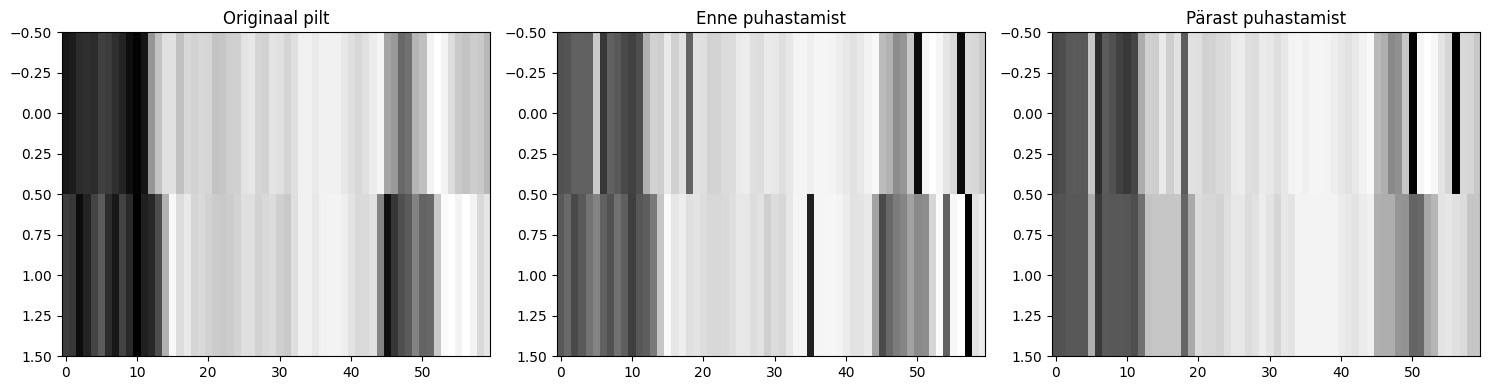

In [464]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Originaal pilt")
plt.imshow(pilt[vaadelavad_indeksid], cmap='gray', aspect='auto')

plt.subplot(1,3,2)
plt.title("Enne puhastamist")
plt.imshow(mürane_pilt[vaadelavad_indeksid], cmap='gray', aspect='auto')

plt.subplot(1,3,3)
plt.title("Pärast puhastamist")
plt.imshow(puhastatud_pilt[vaadelavad_indeksid], cmap='gray', aspect='auto')

plt.tight_layout()
plt.show()

In [465]:
rmse_mürane = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], mürane_pilt[vaadelavad_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], puhastatud_pilt[vaadelavad_indeksid]))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")

RMSE mürane pilt vs originaal: 40.87
RMSE puhastatud pilt vs originaal: 35.67


<font color='red'>Vastus:</font> ...


In [ ]:
# Vaadetes RMSE skoori siis väga suurt muutust polnud, ainult 5 ühikut paremaks läks. Kuid visuaalselt on pilt palju paremini puhastatud.
# Ma arvan et visuaalselt näeb parem välja kuna müra on kohati väga silmatorkav ja seda on silutud rohkem kui RMSE skoori järgi võiks arvata.

# RMSE vahe oli HMM-il ca 10-15 ühikut aga siin on ainult 5 ühikut. seega selle mõõdu järgi ei saa öelda et see oleks parem.

<font color='purple'>**(3b) Kasutage punkti (3a) meetodit, et puhastada mürast meie mürane ristkülik (ka siin tehke protsess kaks korda läbi). Joonistage välja puhastatud pilt. Arvutage RMSE enne ja pärast müra eemaldamist, seejuures RMSE arvutage üle kõigi pikslite mürases ristkülikus (read 20-280 ja veerud 220-280). Kas puhastamine õnnestus paremini või halvemini kui HMM-iga puhastades?**</font>

<font color='purple'>**OODATUD VASTUS: 1 pilt; RMSE enne ja pärast puhastamist; selgitus, kas puhastamine oli edukam kui HMM-iga (1-2 lauset).**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


In [470]:
rows = np.arange(20, 280)
cols = np.arange(220, 280)

puhastatud_pilt = mürane_pilt.copy()

vaadelavad_indeksid = (slice(20, 280), slice(220, 280))

In [ ]:
def faktorite_korrutis(x_ij, i, j):
    y_ij = mürane_pilt[i, j]

    # Naabritega piiramisel kontroll
    #  Ignoreerime seda pikslt kuna tal pole naabrit. korrutis 1-ga ei muuda tulemust
    f1 = freqs[x_ij, puhastatud_pilt[i-1, j]] if i-1 >= 0 else 1
    f2 = freqs[x_ij, puhastatud_pilt[i+1, j]] if i+1 < puhastatud_pilt.shape[0] else 1
    f3 = freqs[x_ij, puhastatud_pilt[i, j-1]] if j-1 >= 0 else 1
    f4 = freqs[x_ij, puhastatud_pilt[i, j+1]] if j+1 < puhastatud_pilt.shape[1] else 1

    # Viies faktor: müra tõenäosus
    f5 = 1 / müra_tõenäosus if x_ij == y_ij else 1

    return f1 * f2 * f3 * f4 * f5

In [471]:
for _ in range(2):
    for i in rows:
        for j in cols:
            parim_x = None
            max_faktor = -np.inf
            for x_ij in range(256):
                faktor = faktorite_korrutis(x_ij, i, j)
                if faktor > max_faktor:
                    max_faktor = faktor
                    parim_x = x_ij
            puhastatud_pilt[i, j] = parim_x


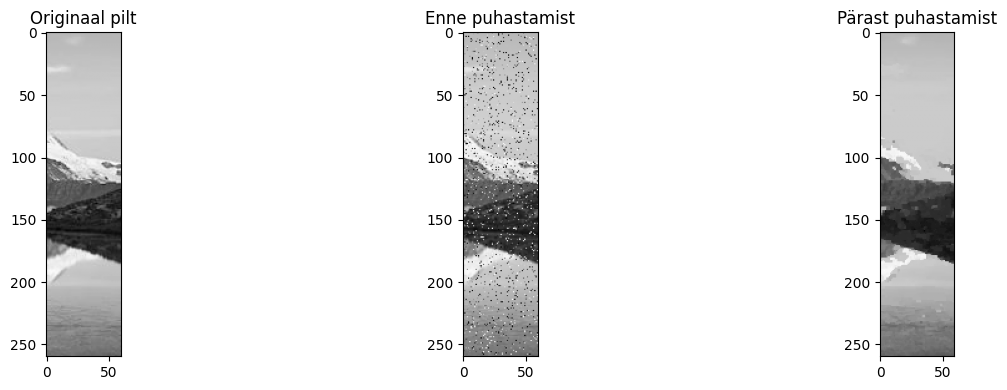

In [473]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Originaal pilt")
plt.imshow(pilt[vaadelavad_indeksid], cmap='gray')

plt.subplot(1,3,2)
plt.title("Enne puhastamist")
plt.imshow(mürane_pilt[vaadelavad_indeksid], cmap='gray')

plt.subplot(1,3,3)
plt.title("Pärast puhastamist")
plt.imshow(puhastatud_pilt[vaadelavad_indeksid], cmap='gray')

plt.tight_layout()
plt.show()

In [474]:
rmse_mürane = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], mürane_pilt[vaadelavad_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], puhastatud_pilt[vaadelavad_indeksid]))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")

RMSE mürane pilt vs originaal: 31.51
RMSE puhastatud pilt vs originaal: 13.10


### <font color='red'> HMM skoor samadel andmetel

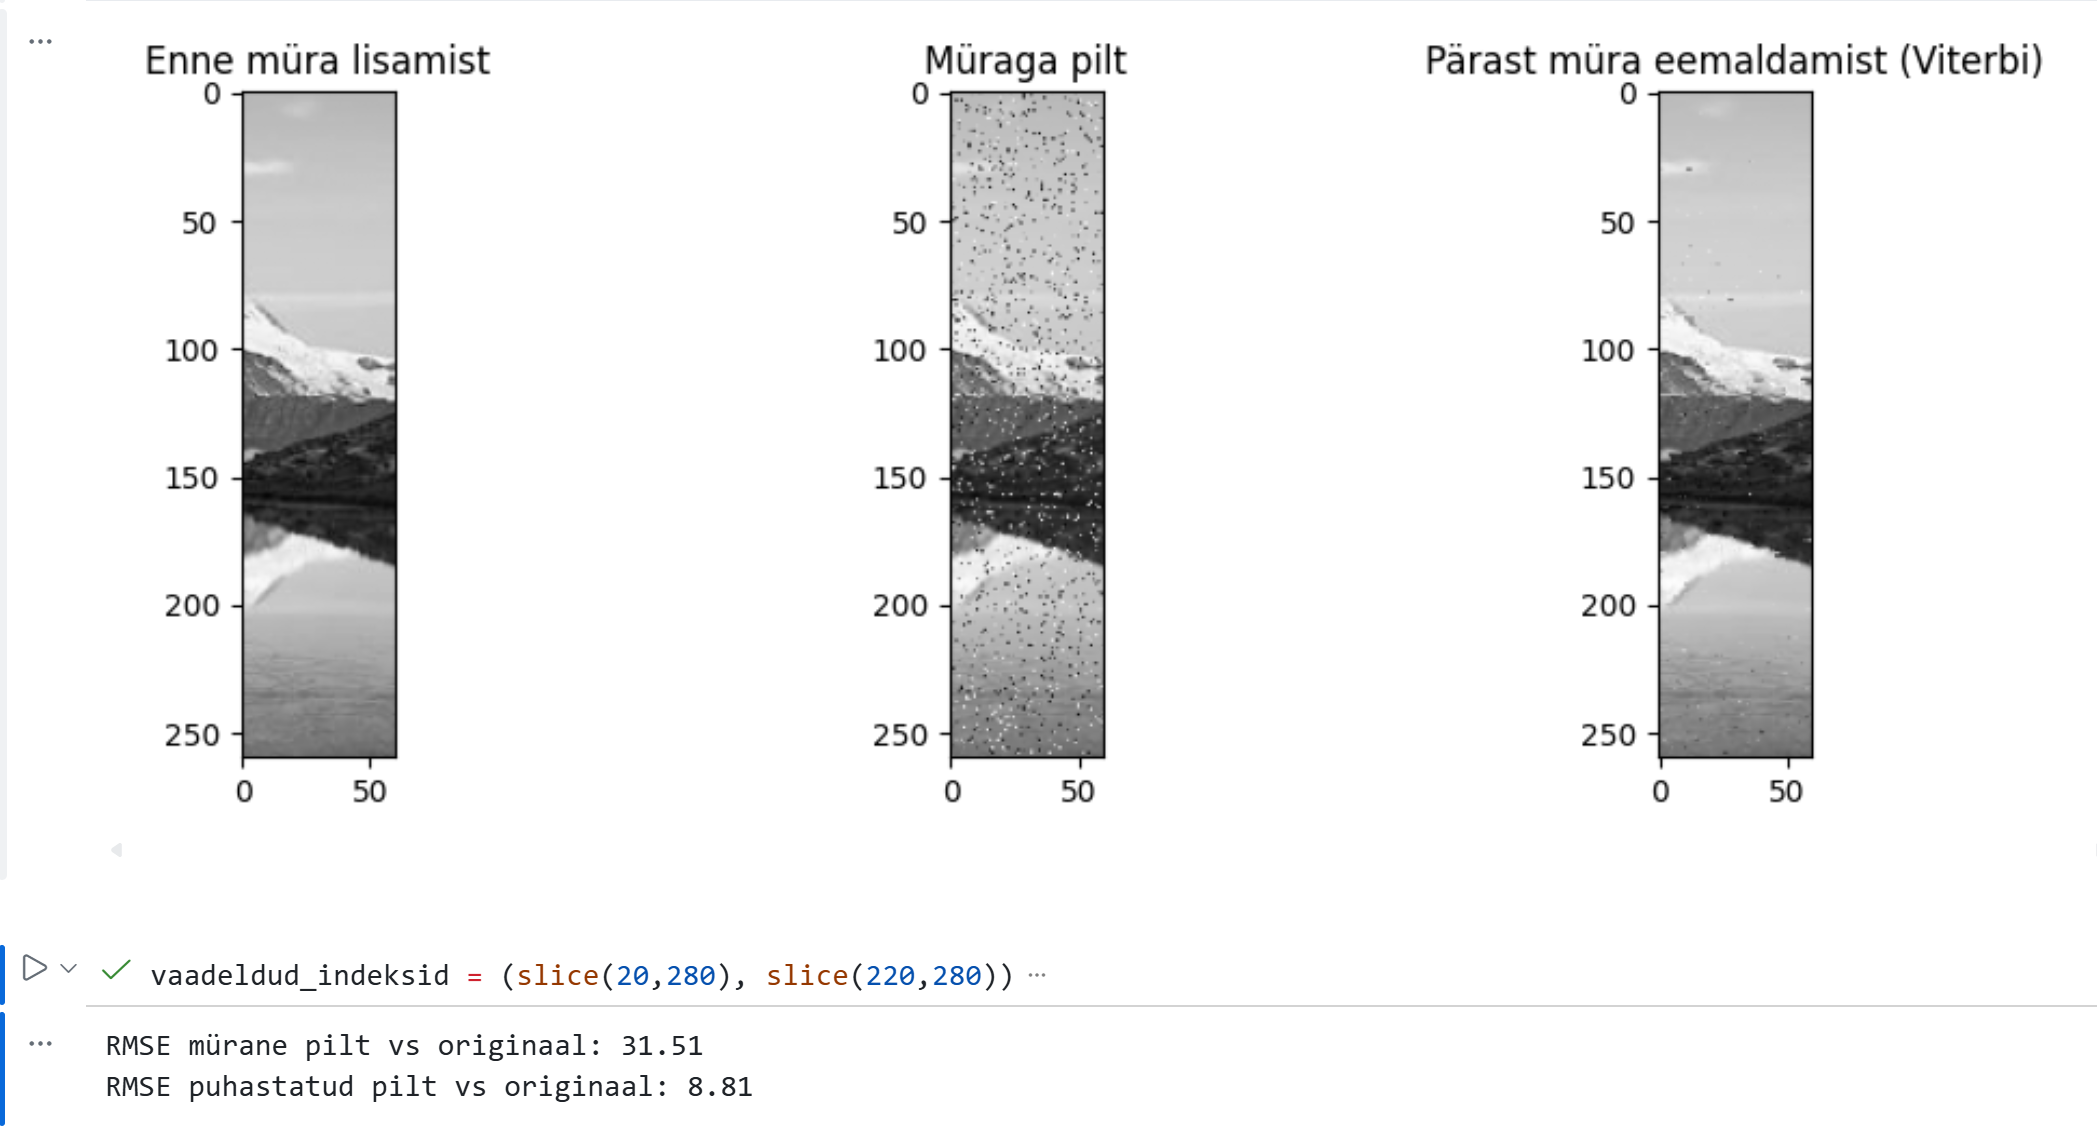


In [ ]:
# Skoor on halvem kui HMM-il aga vsuaalselt on pilt väga hästi puhastatud. Pole suvalisi piksleid mis torkavad kohe silma.

<font color='red'>Vastus:</font> ...


<font color='purple'>**(3c) Puhastage ka eelmise ülesande punktis (2e) loodud pildid `mürane_pilt_03` ja `mürane_pilt_05` (ka siin tehke protsess kaks korda läbi). Joonistage mõlemast müratasemest pilt enne ja pärast puhastamist ning arvutage ka RMSE mürases ristkülikus. Kas mõlemal müratasemel RMSE paranes ning kas puhastamisest oli kasu või kahju? Kuidas olid tulemused võrreldes HMM-iga puhastamisega punktis (2e)?**</font>

<font color='purple'>**OODATUD VASTUS: 4 pilti ja 4 RMSE väärtust (mõlemal müratasemel enne ja pärast müra eemaldamist); selgitus, kas mõlemal müratasemel RMSE kahanes ja kas puhastamine oli edukam kui HMM-iga (2-5 lauset).**</font>

**Küsimus praksi juhendajale:**

**_TEHTUD_** : 1/1


## Mürane pilt 03


RMSE mürane pilt vs originaal: 54.97
RMSE puhastatud pilt vs originaal: 16.09


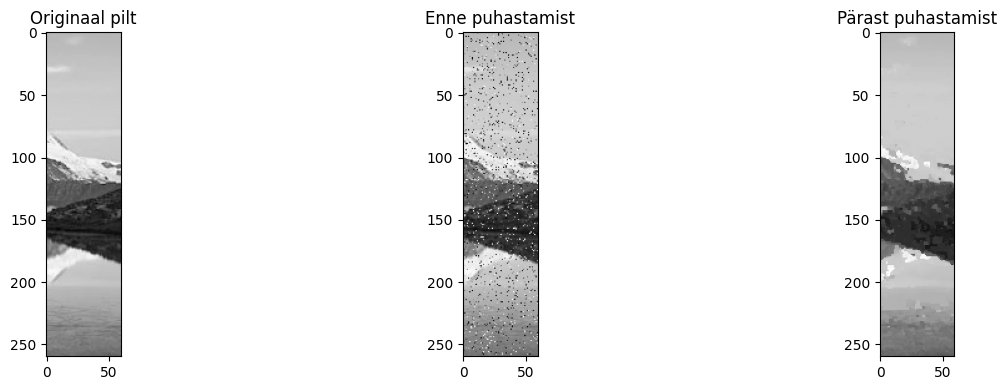

In [477]:
# 03

puhastatud_pilt = mürane_pilt_03.copy()


for _ in range(2):
    for i in rows:
        for j in cols:
            parim_x = None
            max_faktor = -np.inf
            for x_ij in range(256):
                faktor = faktorite_korrutis(x_ij, i, j)
                if faktor > max_faktor:
                    max_faktor = faktor
                    parim_x = x_ij
            puhastatud_pilt[i, j] = parim_x




plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Originaal pilt")
plt.imshow(pilt[vaadelavad_indeksid], cmap='gray')

plt.subplot(1,3,2)
plt.title("Enne puhastamist")
plt.imshow(mürane_pilt[vaadelavad_indeksid], cmap='gray')

plt.subplot(1,3,3)
plt.title("Pärast puhastamist")
plt.imshow(puhastatud_pilt[vaadelavad_indeksid], cmap='gray')

plt.tight_layout()


rmse_mürane = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], mürane_pilt_03[vaadelavad_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], puhastatud_pilt[vaadelavad_indeksid]))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")

### <font color='red'> HMM samadel andmetel

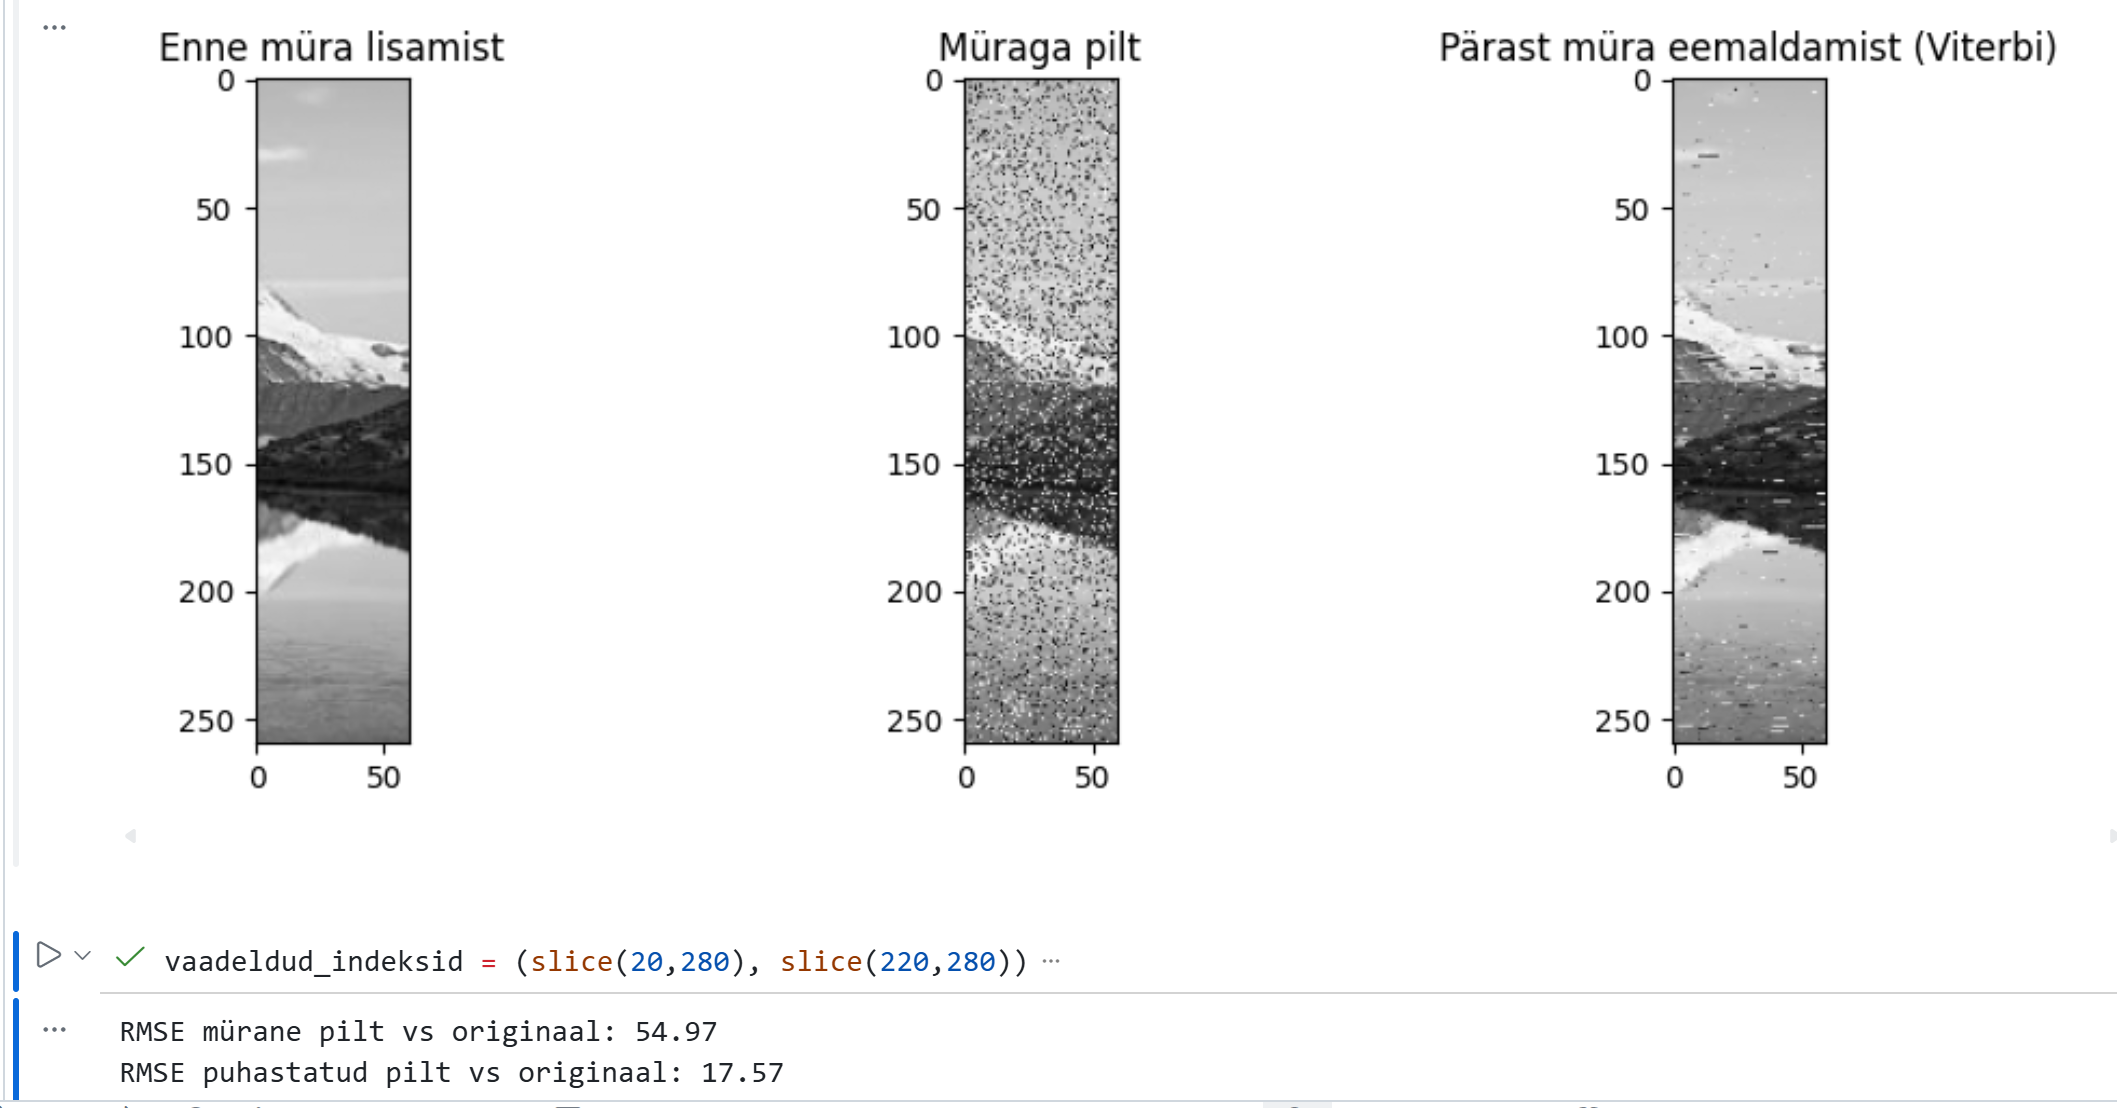


# Mürane pilt 05


RMSE mürane pilt vs originaal: 70.76
RMSE puhastatud pilt vs originaal: 24.58


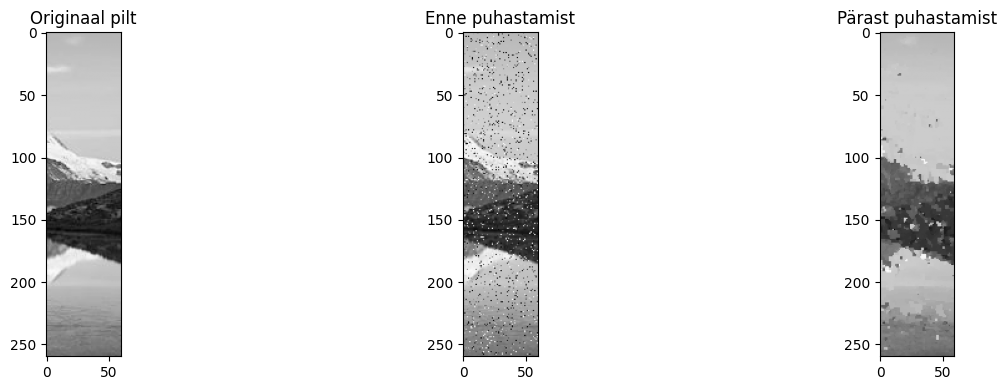

In [478]:
puhastatud_pilt = mürane_pilt_05.copy()


for _ in range(2):
    for i in rows:
        for j in cols:
            parim_x = None
            max_faktor = -np.inf
            for x_ij in range(256):
                faktor = faktorite_korrutis(x_ij, i, j)
                if faktor > max_faktor:
                    max_faktor = faktor
                    parim_x = x_ij
            puhastatud_pilt[i, j] = parim_x




plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Originaal pilt")
plt.imshow(pilt[vaadelavad_indeksid], cmap='gray')

plt.subplot(1,3,2)
plt.title("Enne puhastamist")
plt.imshow(mürane_pilt[vaadelavad_indeksid], cmap='gray')

plt.subplot(1,3,3)
plt.title("Pärast puhastamist")
plt.imshow(puhastatud_pilt[vaadelavad_indeksid], cmap='gray')

plt.tight_layout()


rmse_mürane = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], mürane_pilt_05[vaadelavad_indeksid]))
rmse_puhastatud = sqrt(mean_squared_error(pilt[vaadelavad_indeksid], puhastatud_pilt[vaadelavad_indeksid]))
print(f"RMSE mürane pilt vs originaal: {rmse_mürane:.2f}")
print(f"RMSE puhastatud pilt vs originaal: {rmse_puhastatud:.2f}")

### <font color='red'> HMM samadel andmetel

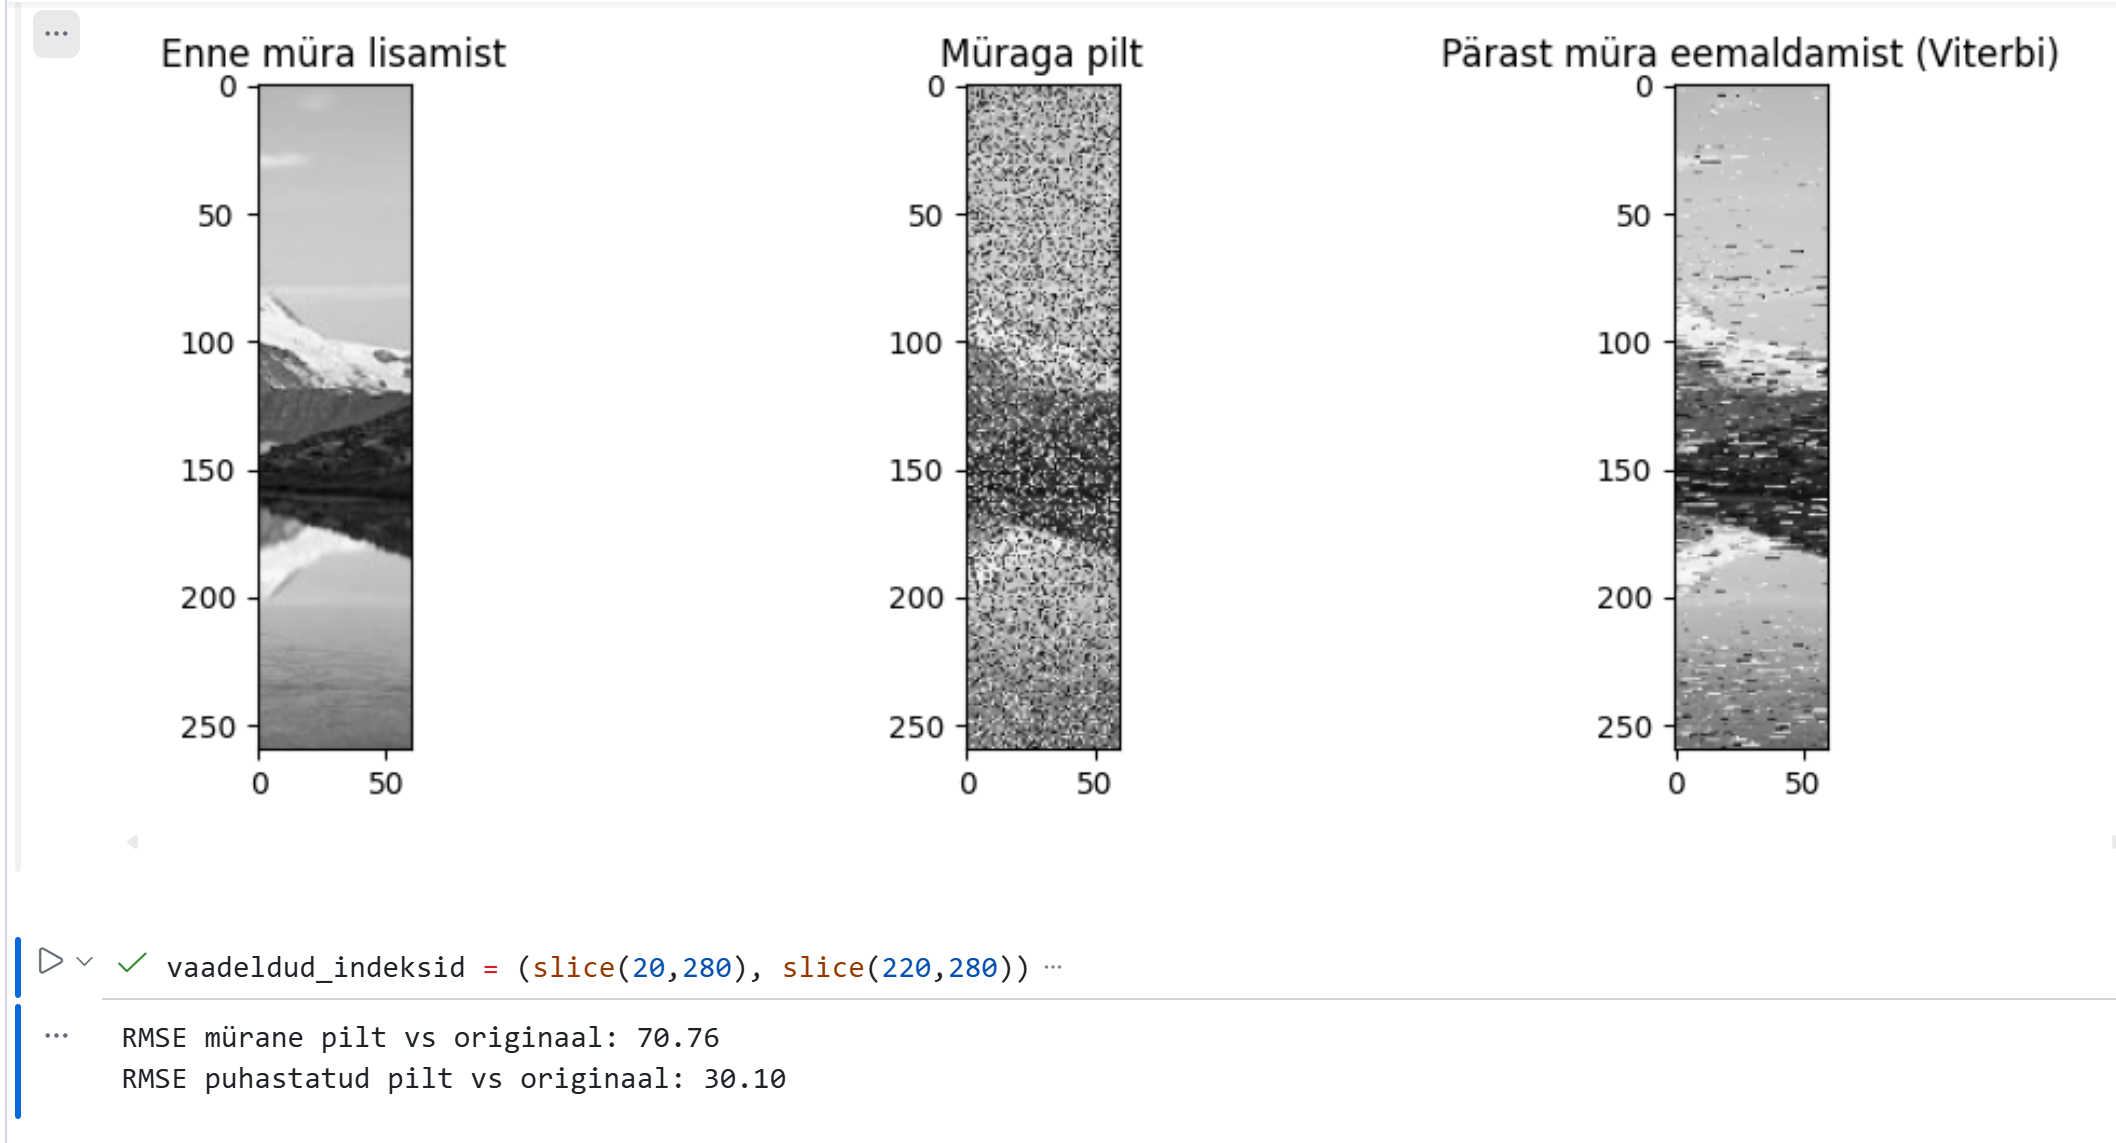


<font color='red'>Vastus:</font> ...


In [ ]:
# Siin said Markovi väljad RMSE skoorid lõpuks paremad kui HMM-il. Lisaks näeb pilt 03 visuaalselt veel väga hea välja. 05 on veidi halvem kuna müra tase on suurem ja seetõttu on ka RMSE skoor halvem. Kuid üldiselt on Markovi väljade meetod siin piltide puhastamisel parem kui HMM.

## <font color='red'>Enne kodutöö esitamist palun lähtesta kernel uuesti ning jooksuta kogu kood algusest peale korra läbi - selleks on vaja menüüst valida `Kernel` -> `Restart and Run All`.</font>

## Kodutöö tagasiside

Palun vasta nii täpselt kui oskad. See ei muuda mingilgi moel punkte, mille kodutöö eest saad. Nii 0,5 tundi kui 24 tundi on sobivad vastused. Kogutud informatsiooni kasutatakse kodutööde paremaks muutmiseks.

<font color = "red">**Tagasidet saad anda anonüümselt siin [Google Formsis](https://forms.gle/nnZwZ6fgpHvx6G1K9).**</font>

**<font color='red'>SUUR TÄNU TEHTUD TÖÖ EEST!</font>**
